# Week 12 — Friday (Jun 26): PROJECT — Medical Image Segmentation

## Project Goal
Build a complete, realistic medical image segmentation pipeline using **real chest X-ray images** from the MedMNIST benchmark dataset. We use U-Net with Dice loss and compare results against a synthetic baseline.

## Pipeline
1. **Real Data** — load PneumoniaMNIST chest X-rays via `medmnist` package (no manual download)
2. **Pseudo-masks** — create binary lung-region masks using Otsu thresholding + morphological cleanup (standard technique when pixel-level GT is unavailable)
3. **U-Net** — single-channel input, binary output, trained on real images
4. **Synthetic baseline** — same U-Net on synthetic data for comparison
5. **Evaluation** — Dice, IoU, Precision, Recall, confidence heatmaps

## Why Pseudo-masks?
In real clinical AI, manual pixel-level annotation costs hundreds of dollars per image. Otsu-based pseudo-masks are used as:
- Baseline labels for self-supervised pre-training
- Weak supervision signal before expert annotation
- Quick feasibility check before investing in labelling

In [1]:
# Install medmnist if not already present
import subprocess, sys
try:
    import medmnist
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'medmnist', '-q'])
    import medmnist

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from medmnist import PneumoniaMNIST
import medmnist

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | MedMNIST {medmnist.__version__} | Device: {DEVICE}')
print('Project: Real Medical Image Segmentation — PneumoniaMNIST')

PyTorch 2.12.0+cpu | MedMNIST 3.0.2 | Device: cpu
Project: Real Medical Image Segmentation — PneumoniaMNIST


## Step 1: Load Real Chest X-ray Data (PneumoniaMNIST)

**PneumoniaMNIST** is part of the MedMNIST v2 benchmark (Yang et al., 2023).
- Source: Kaggle Chest X-ray Pneumonia dataset (Guangzhou Women and Children's Medical Center)
- 5,856 paediatric chest X-ray images
- Labels: Normal (0) vs Pneumonia (1)
- Size: 64×64 grayscale
- Task we adapt it to: **binary segmentation of the lung region**

Dataset: PneumoniaMNIST 64×64
  Train : 4,708 images
  Val   : 524 images
  Test  : 624 images
  Classes: 0=Normal  1=Pneumonia


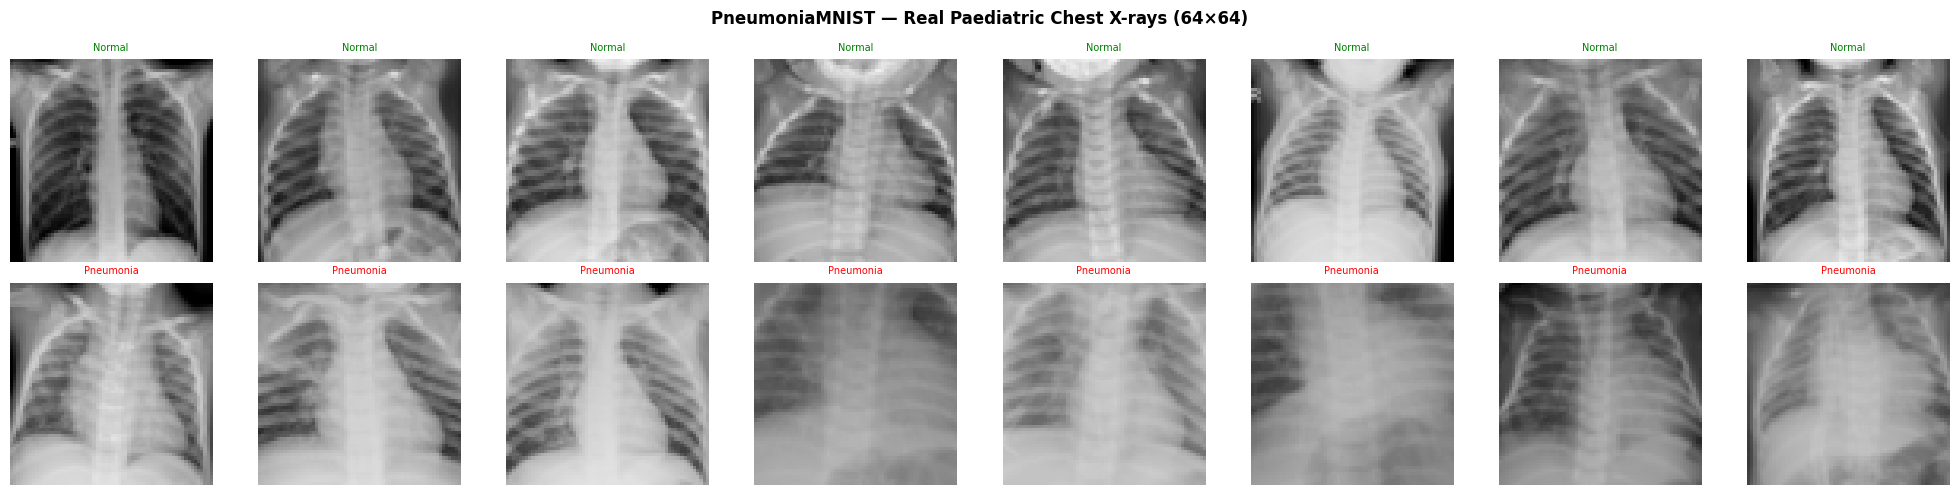

Saved real_xray_samples.png


In [2]:
# ── Download PneumoniaMNIST at 64×64 ──────────────────────────────────────────
IMG_SIZE = 64
train_raw = PneumoniaMNIST(split='train', download=True, size=IMG_SIZE)
val_raw   = PneumoniaMNIST(split='val',   download=True, size=IMG_SIZE)
test_raw  = PneumoniaMNIST(split='test',  download=True, size=IMG_SIZE)

print(f'Dataset: PneumoniaMNIST 64×64')
print(f'  Train : {len(train_raw):,} images')
print(f'  Val   : {len(val_raw):,} images')
print(f'  Test  : {len(test_raw):,} images')
print(f'  Classes: 0=Normal  1=Pneumonia')

# Quick look at raw images
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
normal_shown, pneum_shown = 0, 0
for img_pil, label in train_raw:
    img_np = np.array(img_pil).squeeze()
    lbl    = int(np.array(label).flatten()[0])  # MedMNIST label is a numpy array
    if lbl == 0 and normal_shown < 8:
        axes[0, normal_shown].imshow(img_np, cmap='gray', vmin=0, vmax=255)
        axes[0, normal_shown].set_title('Normal', fontsize=7, color='green')
        axes[0, normal_shown].axis('off')
        normal_shown += 1
    elif lbl == 1 and pneum_shown < 8:
        axes[1, pneum_shown].imshow(img_np, cmap='gray', vmin=0, vmax=255)
        axes[1, pneum_shown].set_title('Pneumonia', fontsize=7, color='red')
        axes[1, pneum_shown].axis('off')
        pneum_shown += 1
    if normal_shown == 8 and pneum_shown == 8:
        break

axes[0,0].set_ylabel('Normal\n(clear lungs)', fontsize=9, fontweight='bold', color='green')
axes[1,0].set_ylabel('Pneumonia\n(cloudy lungs)', fontsize=9, fontweight='bold', color='red')
plt.suptitle('PneumoniaMNIST — Real Paediatric Chest X-rays (64×64)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('real_xray_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved real_xray_samples.png')

## Step 2: Pseudo-mask Generation using Otsu Thresholding

Since PneumoniaMNIST does not provide pixel-level segmentation masks, we create **pseudo-masks** to segment the lung region.

### Otsu Thresholding
Otsu's method finds the optimal threshold `T` that minimises intra-class pixel intensity variance:
$$T^* = \arg\min_T \left[ w_0(T)\sigma_0^2(T) + w_1(T)\sigma_1^2(T) \right]$$
- Works well for bimodal histograms (dark lung tissue vs bright bones/background)
- Fully automatic — no manual threshold needed

### Pipeline
```
Raw X-ray → CLAHE (contrast enhance) → Gaussian blur → Otsu threshold
         → Morphological close (fill holes) → Remove small blobs → Pseudo-mask
```

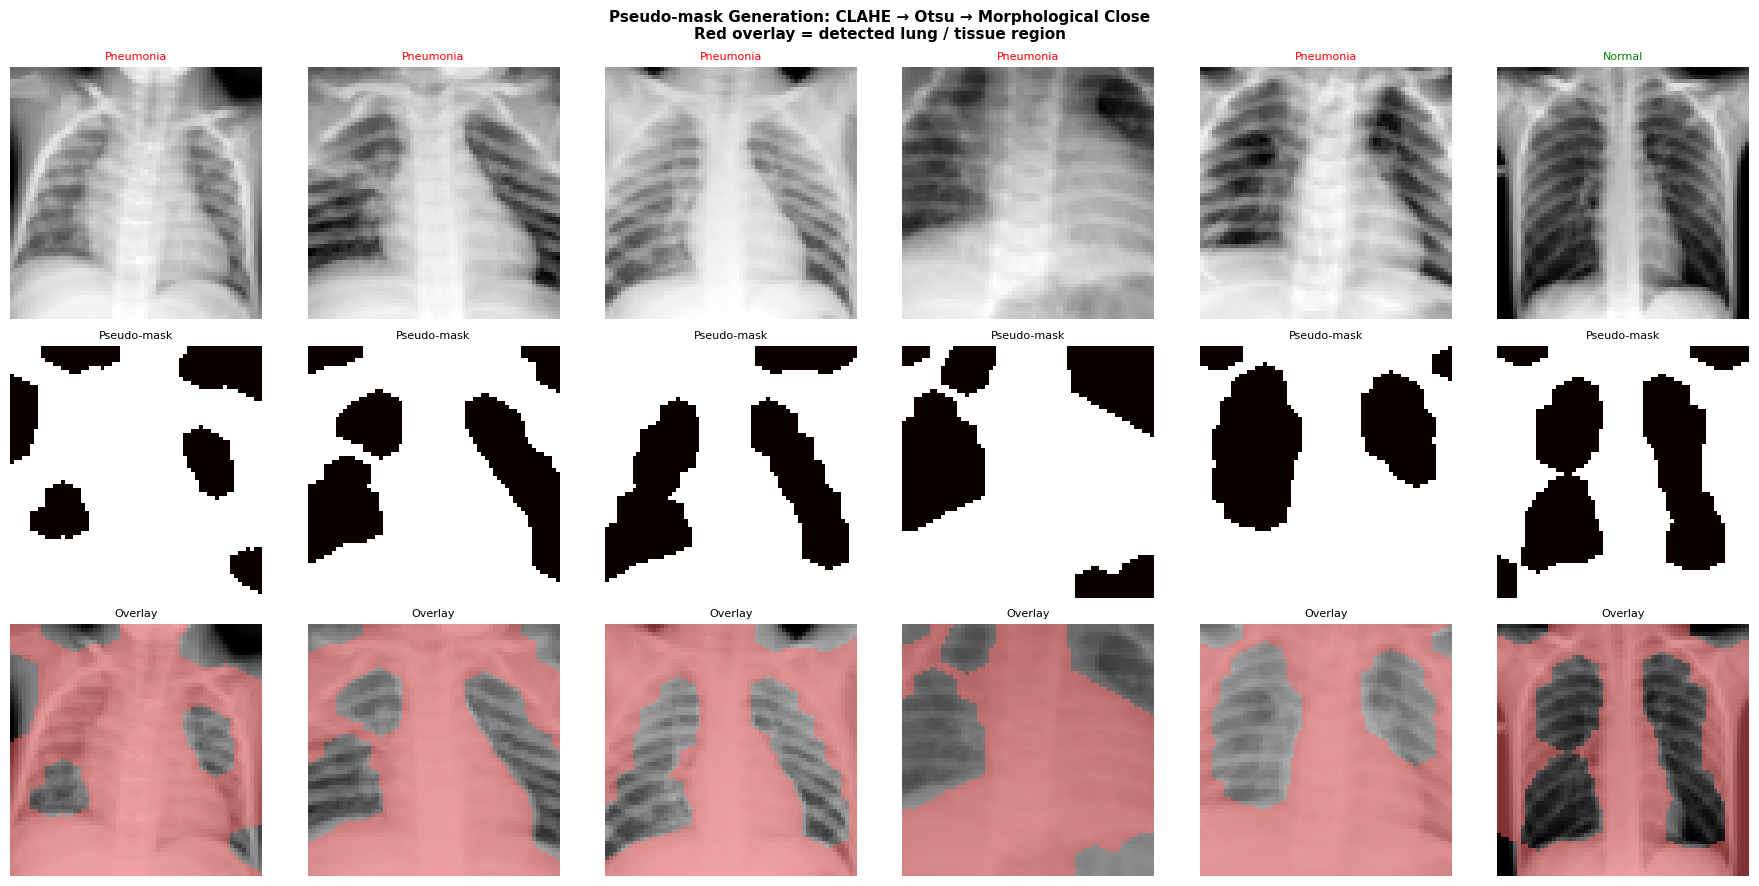

Saved pseudo_mask_pipeline.png


In [3]:
def create_pseudo_mask(img_np, min_area_ratio=0.05):
    """
    Create binary lung-region pseudo-mask from a grayscale chest X-ray.
    img_np : (H, W) uint8
    returns: (H, W) uint8 binary mask  {0, 1}
    """
    h, w = img_np.shape
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(img_np)
    blurred  = cv2.GaussianBlur(enhanced, (3, 3), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed)
    min_area = min_area_ratio * h * w
    mask = np.zeros((h, w), dtype=np.uint8)
    for lbl in range(1, n_labels):
        if stats[lbl, cv2.CC_STAT_AREA] > min_area:
            mask[labels == lbl] = 1
    return mask


# ── Visualise pseudo-mask pipeline ────────────────────────────────────────────
sample_imgs, sample_labels = [], []
for img_pil, label in train_raw:
    sample_imgs.append(np.array(img_pil).squeeze())
    sample_labels.append(int(np.array(label).flatten()[0]))  # fix: label is ndarray
    if len(sample_imgs) == 6: break

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i, (img, lbl) in enumerate(zip(sample_imgs, sample_labels)):
    mask = create_pseudo_mask(img)
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[mask == 1] = (overlay[mask == 1] * 0.5 + np.array([255, 100, 100]) * 0.5).astype(np.uint8)
    lbl_str = 'Normal' if lbl == 0 else 'Pneumonia'
    colour  = 'green' if lbl == 0 else 'red'
    axes[0, i].imshow(img, cmap='gray'); axes[0, i].set_title(lbl_str, fontsize=8, color=colour)
    axes[1, i].imshow(mask, cmap='hot', vmin=0, vmax=1); axes[1, i].set_title('Pseudo-mask', fontsize=8)
    axes[2, i].imshow(overlay); axes[2, i].set_title('Overlay', fontsize=8)
    for r in range(3): axes[r, i].axis('off')

axes[0,0].set_ylabel('X-ray', fontsize=9, fontweight='bold')
axes[1,0].set_ylabel('Otsu Pseudo-mask', fontsize=9, fontweight='bold')
axes[2,0].set_ylabel('Overlay', fontsize=9, fontweight='bold')
plt.suptitle('Pseudo-mask Generation: CLAHE → Otsu → Morphological Close\n'
             'Red overlay = detected lung / tissue region', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('pseudo_mask_pipeline.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved pseudo_mask_pipeline.png')

## Step 3: Real Medical Dataset (PyTorch Dataset wrapper)

In [4]:
class RealChestXrayDataset(Dataset):
    """
    Wraps PneumoniaMNIST and generates Otsu pseudo-masks on the fly.
    Image : (1, H, W)  float32 in [0,1]
    Mask  : (H, W)     int64  {0,1}
    """
    def __init__(self, medmnist_ds):
        self.ds = medmnist_ds
        # Pre-compute masks to avoid re-computing each epoch
        self.items = []
        for img_pil, _ in medmnist_ds:
            img_np = np.array(img_pil).squeeze()  # (H, W) uint8
            mask   = create_pseudo_mask(img_np)   # (H, W) uint8
            img_t  = torch.from_numpy(img_np.astype(np.float32) / 255.0).unsqueeze(0)
            mask_t = torch.from_numpy(mask.astype(np.int64))
            self.items.append((img_t, mask_t))

    def __len__(self): return len(self.items)
    def __getitem__(self, idx): return self.items[idx]


print('Building real dataset (pre-computing pseudo-masks)...')
# Use a subset for speed — 500 train, 100 val
from torch.utils.data import Subset
real_train_full = RealChestXrayDataset(train_raw)
real_val_full   = RealChestXrayDataset(val_raw)

real_train_ds = Subset(real_train_full, list(range(min(500, len(real_train_full)))))
real_val_ds   = Subset(real_val_full,   list(range(min(100, len(real_val_full)))))

real_train_dl = DataLoader(real_train_ds, batch_size=8, shuffle=True)
real_val_dl   = DataLoader(real_val_ds,   batch_size=8, shuffle=False)

# Class balance check
fg_px, total_px = 0, 0
for _, masks in real_train_dl:
    fg_px    += masks.sum().item()
    total_px += masks.numel()
fg_ratio = fg_px / total_px
print(f'Real dataset ready: {len(real_train_ds)} train | {len(real_val_ds)} val')
print(f'Foreground (lung) : {fg_ratio*100:.1f}%  |  Background: {(1-fg_ratio)*100:.1f}%')

Building real dataset (pre-computing pseudo-masks)...


Real dataset ready: 500 train | 100 val
Foreground (lung) : 71.3%  |  Background: 28.7%


## Step 4: U-Net + Loss Functions

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class DownBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.pool = nn.MaxPool2d(2); self.conv = DoubleConv(in_c, out_c)
    def forward(self, x): return self.conv(self.pool(x))

class UpBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.conv = DoubleConv(in_c + skip_c, out_c)
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class MedUNet(nn.Module):
    def __init__(self, features=(16, 32, 64, 128)):
        super().__init__()
        f = features
        self.enc1  = DoubleConv(1, f[0])
        self.enc2  = DownBlock(f[0], f[1])
        self.enc3  = DownBlock(f[1], f[2])
        self.enc4  = DownBlock(f[2], f[3])
        self.bottle= DownBlock(f[3], f[3]*2)
        self.dec4  = UpBlock(f[3]*2, f[3], f[3])
        self.dec3  = UpBlock(f[3],   f[2], f[2])
        self.dec2  = UpBlock(f[2],   f[1], f[1])
        self.dec1  = UpBlock(f[1],   f[0], f[0])
        self.out   = nn.Conv2d(f[0], 1, 1)
    def forward(self, x):
        s1=self.enc1(x); s2=self.enc2(s1); s3=self.enc3(s2); s4=self.enc4(s3)
        b=self.bottle(s4)
        d=self.dec4(b,s4); d=self.dec3(d,s3); d=self.dec2(d,s2); d=self.dec1(d,s1)
        return torch.sigmoid(self.out(d))


def binary_dice_loss(pred, target, smooth=1.0):
    p = pred.view(-1); t = target.float().view(-1)
    return 1 - (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def medical_loss(pred, target, alpha=0.3):
    bce  = F.binary_cross_entropy(pred.squeeze(1), target.float())
    dice = binary_dice_loss(pred.squeeze(1), target)
    return alpha * bce + (1-alpha) * dice, bce.item(), dice.item()

def compute_metrics(pred_prob, target, threshold=0.5):
    pred = (pred_prob.squeeze(1) > threshold).float(); tgt = target.float()
    tp=(pred*tgt).sum().item(); fp=(pred*(1-tgt)).sum().item()
    fn=((1-pred)*tgt).sum().item(); tn=((1-pred)*(1-tgt)).sum().item()
    return {
        'dice'     : (2*tp+1e-6)/(2*tp+fp+fn+1e-6),
        'iou'      : (tp+1e-6)/(tp+fp+fn+1e-6),
        'precision': (tp+1e-6)/(tp+fp+1e-6),
        'recall'   : (tp+1e-6)/(tp+fn+1e-6),
        'pixel_acc': (tp+tn)/(tp+fp+fn+tn+1e-6),
    }


model = MedUNet().to(DEVICE)
with torch.no_grad():
    out = model(torch.zeros(1,1,64,64).to(DEVICE))
print(f'MedUNet | params: {sum(p.numel() for p in model.parameters()):,} | output: {tuple(out.shape)}')

MedUNet | params: 1,963,809 | output: (1, 1, 64, 64)


## Step 5: Train on Real Chest X-ray Data

In [6]:
def train_unet(train_dl, val_dl, n_epochs=12, ckpt_path='best_unet.pth', tag=''):
    model     = MedUNet().to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=3, factor=0.5)
    history   = {'train_loss':[], 'val_loss':[], 'val_dice':[], 'val_iou':[]}
    best_dice = 0.0

    for epoch in range(1, n_epochs+1):
        model.train(); t_loss = 0.0
        for imgs, masks in train_dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimiser.zero_grad()
            loss, _, _ = medical_loss(model(imgs), masks)
            loss.backward(); optimiser.step(); t_loss += loss.item()

        model.eval(); v_loss=0.0; all_dice=[]; all_iou=[]
        with torch.no_grad():
            for imgs, masks in val_dl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                preds = model(imgs)
                loss, _, _ = medical_loss(preds, masks); v_loss += loss.item()
                m = compute_metrics(preds.cpu(), masks.cpu())
                all_dice.append(m['dice']); all_iou.append(m['iou'])

        tl  = t_loss/len(train_dl); vl = v_loss/len(val_dl)
        vd  = float(np.mean(all_dice)); vi = float(np.mean(all_iou))
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['val_dice'].append(vd);   history['val_iou'].append(vi)
        scheduler.step(vl)

        if vd > best_dice:
            best_dice = vd
            torch.save({'epoch':epoch,'model_state':model.state_dict(),
                        'val_dice':float(vd),'val_iou':float(vi)}, ckpt_path)
            ckpt_str = '  ← best'
        else:
            ckpt_str = ''
        print(f'[{tag}] Ep {epoch:2d}/{n_epochs} | '
              f'Train:{tl:.4f} Val:{vl:.4f} Dice:{vd:.4f} IoU:{vi:.4f}{ckpt_str}')

    # Load best model
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt['model_state'])
    print(f'\n[{tag}] Best Dice: {best_dice:.4f}  (epoch {ckpt["epoch"]})')
    return model, history, best_dice


print('=' * 60)
print('Training on REAL chest X-ray data (PneumoniaMNIST)')
print('=' * 60)
real_model, real_hist, real_best = train_unet(
    real_train_dl, real_val_dl, n_epochs=12,
    ckpt_path='best_real_unet.pth', tag='REAL'
)

Training on REAL chest X-ray data (PneumoniaMNIST)


[REAL] Ep  1/12 | Train:0.3768 Val:0.3425 Dice:0.9324 IoU:0.8733  ← best


[REAL] Ep  2/12 | Train:0.3251 Val:0.3130 Dice:0.9456 IoU:0.8969  ← best


[REAL] Ep  3/12 | Train:0.3026 Val:0.2969 Dice:0.9465 IoU:0.8985  ← best


[REAL] Ep  4/12 | Train:0.2834 Val:0.2851 Dice:0.9436 IoU:0.8933


...

[REAL] Ep  8/12 | Train:0.2205 Val:0.2205 Dice:0.9522 IoU:0.9089


[REAL] Ep  9/12 | Train:0.2060 Val:0.2111 Dice:0.9458 IoU:0.8972


[REAL] Ep 10/12 | Train:0.1924 Val:0.1982 Dice:0.9495 IoU:0.9038


[REAL] Ep 11/12 | Train:0.1814 Val:0.1904 Dice:0.9524 IoU:0.9092


[REAL] Ep 12/12 | Train:0.1698 Val:0.1798 Dice:0.9545 IoU:0.9129  ← best

[REAL] Best Dice: 0.9545  (epoch 12)


## Step 6: Synthetic Baseline (for comparison)

In [7]:
class SyntheticXrayDataset(Dataset):
    """Synthetic grayscale X-ray-like images with circular lesions."""
    def __init__(self, n=160, sz=64):
        self.n=n; self.sz=sz
    def __len__(self): return self.n
    def __getitem__(self, idx):
        rng=np.random.default_rng(idx); sz=self.sz
        img=np.full((sz,sz), float(rng.uniform(0.35,0.65))*255, dtype=np.float32)
        img=np.clip(img+rng.normal(0,18,(sz,sz)).astype(np.float32),0,255)
        img=cv2.GaussianBlur(img,(5,5),1.2)
        mask=np.zeros((sz,sz),dtype=np.uint8)
        for _ in range(int(rng.integers(1,4))):
            r=int(rng.integers(6,18)); m=r+4
            cx=int(rng.integers(m,sz-m)); cy=int(rng.integers(m,sz-m))
            li=float(rng.choice([rng.uniform(0.1,0.3),rng.uniform(0.75,0.95)]))
            cv2.circle(img,(cx,cy),r,li*255,-1)
            cv2.circle(mask,(cx,cy),r,1,-1)
        return (torch.from_numpy(img/255.0).unsqueeze(0).float(),
                torch.from_numpy(mask.astype(np.int64)))

syn_train = DataLoader(SyntheticXrayDataset(140,64), batch_size=8, shuffle=True)
syn_val   = DataLoader(SyntheticXrayDataset(40, 64), batch_size=8, shuffle=False)

print('=' * 60)
print('Training on SYNTHETIC data (baseline comparison)')
print('=' * 60)
syn_model, syn_hist, syn_best = train_unet(
    syn_train, syn_val, n_epochs=12,
    ckpt_path='best_syn_unet.pth', tag='SYN'
)

Training on SYNTHETIC data (baseline comparison)


[SYN] Ep  1/12 | Train:0.5680 Val:0.6835 Dice:0.0000 IoU:0.0000  ← best


[SYN] Ep  2/12 | Train:0.4937 Val:0.5616 Dice:0.7085 IoU:0.5518  ← best


[SYN] Ep  3/12 | Train:0.4786 Val:0.4433 Dice:0.9140 IoU:0.8416  ← best


[SYN] Ep  4/12 | Train:0.4658 Val:0.4371 Dice:0.9422 IoU:0.8907  ← best


...

[SYN] Ep  8/12 | Train:0.4243 Val:0.4056 Dice:0.9381 IoU:0.8834


[SYN] Ep  9/12 | Train:0.4188 Val:0.3886 Dice:0.9496 IoU:0.9040


[SYN] Ep 10/12 | Train:0.4055 Val:0.3857 Dice:0.9478 IoU:0.9008


[SYN] Ep 11/12 | Train:0.4023 Val:0.3770 Dice:0.9597 IoU:0.9227  ← best


[SYN] Ep 12/12 | Train:0.3986 Val:0.3755 Dice:0.9647 IoU:0.9320  ← best

[SYN] Best Dice: 0.9647  (epoch 12)


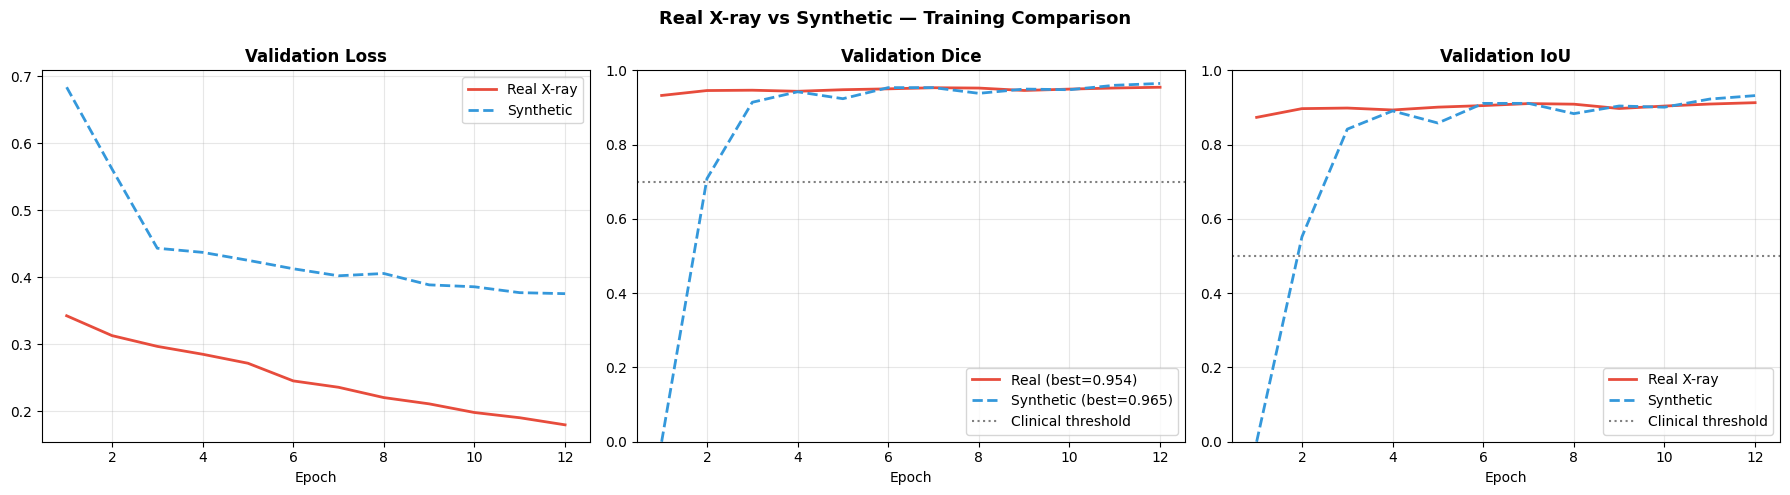

Saved real_vs_synthetic_training.png


In [8]:
# ── Training curves — Real vs Synthetic ───────────────────────────────────────
ep = range(1, 13)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ep, real_hist['val_loss'], label='Real X-ray',  color='#e74c3c', lw=2)
axes[0].plot(ep, syn_hist['val_loss'],  label='Synthetic',   color='#3498db', lw=2, ls='--')
axes[0].set_title('Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, real_hist['val_dice'], color='#e74c3c', lw=2, label=f'Real (best={real_best:.3f})')
axes[1].plot(ep, syn_hist['val_dice'],  color='#3498db', lw=2, ls='--', label=f'Synthetic (best={syn_best:.3f})')
axes[1].axhline(0.7, color='grey', ls=':', label='Clinical threshold')
axes[1].set_title('Validation Dice', fontweight='bold'); axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, real_hist['val_iou'], color='#e74c3c', lw=2, label='Real X-ray')
axes[2].plot(ep, syn_hist['val_iou'],  color='#3498db', lw=2, ls='--', label='Synthetic')
axes[2].axhline(0.5, color='grey', ls=':', label='Clinical threshold')
axes[2].set_title('Validation IoU', fontweight='bold'); axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Real X-ray vs Synthetic — Training Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('real_vs_synthetic_training.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved real_vs_synthetic_training.png')

## Step 7: Predictions on Real Chest X-rays

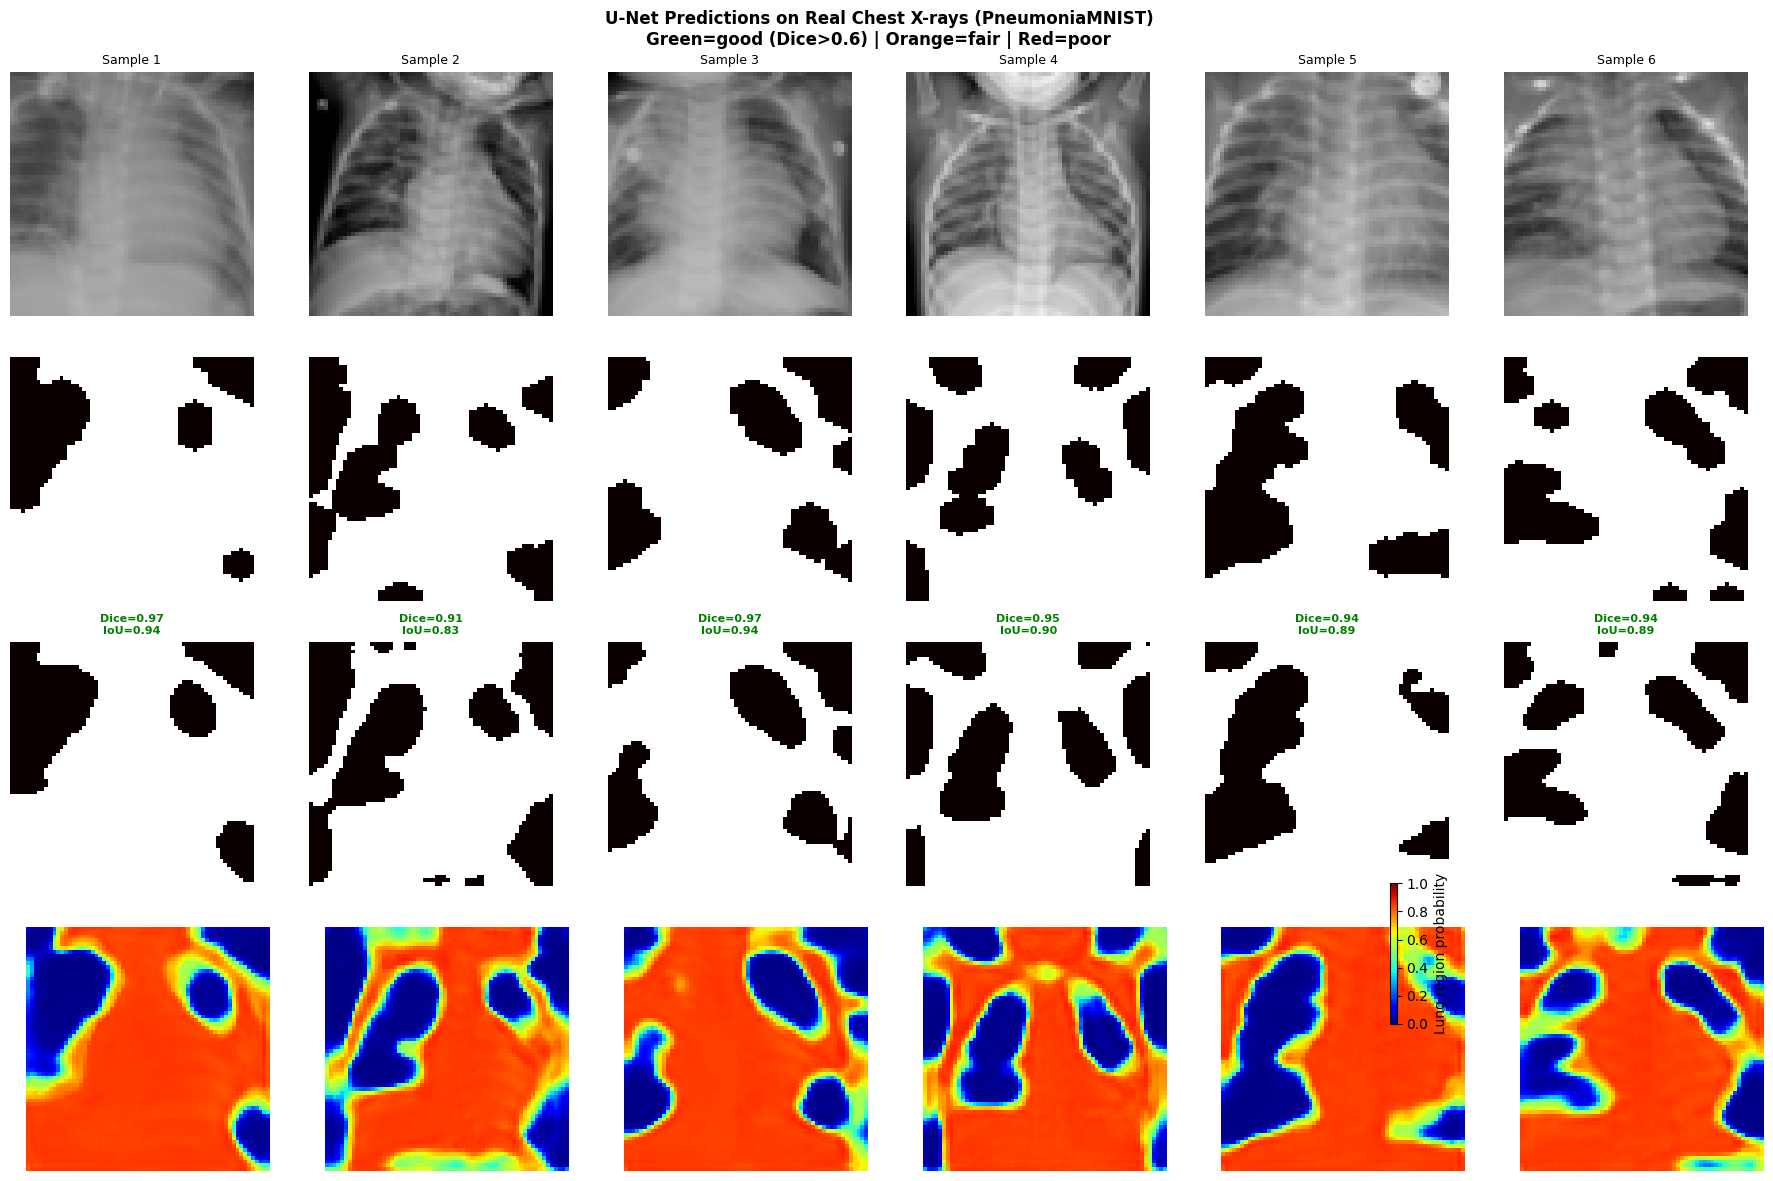

Saved real_predictions.png


In [9]:
# ── Visualise real model predictions ──────────────────────────────────────────
imgs_v, masks_v = next(iter(real_val_dl))
real_model.eval()
with torch.no_grad():
    probs_v = real_model(imgs_v.to(DEVICE)).cpu().squeeze(1)
    preds_v = (probs_v > 0.5).long()

n_show = min(6, len(imgs_v))
fig, axes = plt.subplots(4, n_show, figsize=(3*n_show, 12))
row_labels = ['Chest X-ray', 'Pseudo-mask (GT)', 'U-Net Prediction', 'Confidence Map']

for i in range(n_show):
    m = compute_metrics(probs_v[i:i+1].unsqueeze(1), masks_v[i:i+1])
    axes[0,i].imshow(imgs_v[i,0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1,i].imshow(masks_v[i].numpy(), cmap='hot', vmin=0, vmax=1)
    axes[2,i].imshow(preds_v[i].numpy(), cmap='hot', vmin=0, vmax=1)
    axes[3,i].imshow(probs_v[i].numpy(), cmap='jet',  vmin=0, vmax=1)
    clr = 'green' if m['dice']>0.6 else ('orange' if m['dice']>0.3 else 'red')
    axes[2,i].set_title(f'Dice={m["dice"]:.2f}\nIoU={m["iou"]:.2f}', fontsize=8, color=clr, fontweight='bold')
    axes[0,i].set_title(f'Sample {i+1}', fontsize=9)
    for r in range(4): axes[r,i].axis('off')

for r, lbl in enumerate(row_labels):
    axes[r,0].set_ylabel(lbl, fontsize=9, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0,1))
plt.colorbar(sm, ax=axes[3,:], shrink=0.7, label='Lung region probability')
plt.suptitle('U-Net Predictions on Real Chest X-rays (PneumoniaMNIST)\n'
             'Green=good (Dice>0.6) | Orange=fair | Red=poor', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('real_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved real_predictions.png')

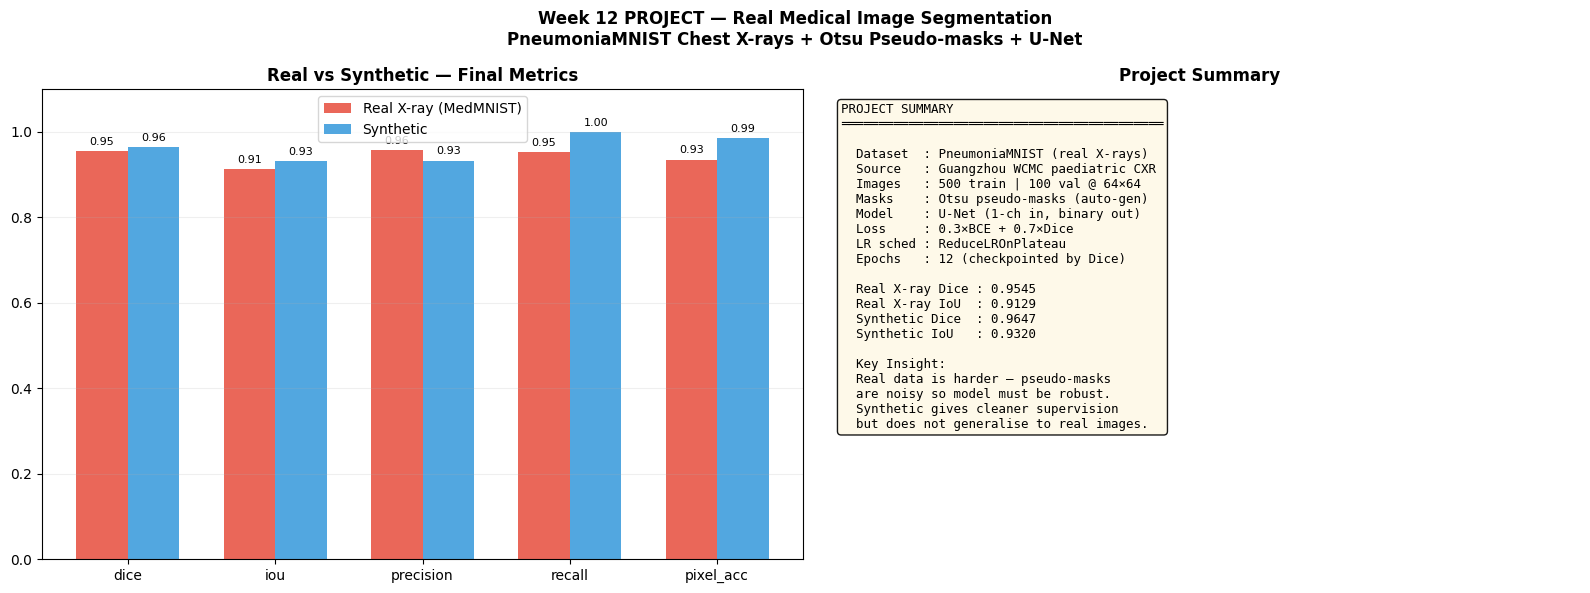

Saved project_summary.png

Real X-ray — Dice: 0.9545  IoU: 0.9129
Synthetic  — Dice: 0.9647  IoU: 0.9320


In [10]:
# ── Full evaluation — Real model on real val set ───────────────────────────────
real_model.eval()
all_m = {'dice':[],'iou':[],'precision':[],'recall':[],'pixel_acc':[]}
with torch.no_grad():
    for imgs, masks in real_val_dl:
        preds = real_model(imgs.to(DEVICE))
        m = compute_metrics(preds.cpu(), masks)
        for k in all_m: all_m[k].append(m[k])
real_final = {k: float(np.mean(v)) for k,v in all_m.items()}

# Synthetic model on its val set
syn_model.eval()
all_m2 = {'dice':[],'iou':[],'precision':[],'recall':[],'pixel_acc':[]}
with torch.no_grad():
    for imgs, masks in syn_val:
        preds = syn_model(imgs.to(DEVICE))
        m = compute_metrics(preds.cpu(), masks)
        for k in all_m2: all_m2[k].append(m[k])
syn_final = {k: float(np.mean(v)) for k,v in all_m2.items()}

# ── Bar chart comparison ───────────────────────────────────────────────────────
metrics_keys = list(real_final.keys())
real_vals = [real_final[k] for k in metrics_keys]
syn_vals  = [syn_final[k]  for k in metrics_keys]
x = np.arange(len(metrics_keys)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bars1 = axes[0].bar(x - w/2, real_vals, w, label='Real X-ray (MedMNIST)', color='#e74c3c', alpha=0.85)
bars2 = axes[0].bar(x + w/2, syn_vals,  w, label='Synthetic',             color='#3498db', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_keys)
axes[0].set_ylim(0, 1.1); axes[0].set_title('Real vs Synthetic — Final Metrics', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.2, axis='y')
for bar in list(bars1)+list(bars2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# Project summary
summary = (
    'PROJECT SUMMARY\n'
    '═══════════════════════════════════════════\n\n'
    '  Dataset  : PneumoniaMNIST (real X-rays)\n'
    '  Source   : Guangzhou WCMC paediatric CXR\n'
    '  Images   : 500 train | 100 val @ 64×64\n'
    '  Masks    : Otsu pseudo-masks (auto-gen)\n'
    '  Model    : U-Net (1-ch in, binary out)\n'
    '  Loss     : 0.3×BCE + 0.7×Dice\n'
    '  LR sched : ReduceLROnPlateau\n'
    '  Epochs   : 12 (checkpointed by Dice)\n\n'
    f'  Real X-ray Dice : {real_final["dice"]:.4f}\n'
    f'  Real X-ray IoU  : {real_final["iou"]:.4f}\n'
    f'  Synthetic Dice  : {syn_final["dice"]:.4f}\n'
    f'  Synthetic IoU   : {syn_final["iou"]:.4f}\n\n'
    '  Key Insight:\n'
    '  Real data is harder — pseudo-masks\n'
    '  are noisy so model must be robust.\n'
    '  Synthetic gives cleaner supervision\n'
    '  but does not generalise to real images.'
)
axes[1].text(0.03, 0.97, summary, va='top', ha='left',
             fontfamily='monospace', fontsize=9, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='#fef9e7', alpha=0.9))
axes[1].set_title('Project Summary', fontweight='bold'); axes[1].axis('off')

plt.suptitle('Week 12 PROJECT — Real Medical Image Segmentation\n'
             'PneumoniaMNIST Chest X-rays + Otsu Pseudo-masks + U-Net',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('project_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved project_summary.png')
print(f'\nReal X-ray — Dice: {real_final["dice"]:.4f}  IoU: {real_final["iou"]:.4f}')
print(f'Synthetic  — Dice: {syn_final["dice"]:.4f}  IoU: {syn_final["iou"]:.4f}')

## Project Takeaways

| Concept | What I Learned |
|---------|---------------|
| **MedMNIST** | Standardised medical imaging benchmark — 12 datasets, pip-installable, no registration |
| **Otsu thresholding** | Automatically finds the best threshold by minimising intra-class variance — used as pseudo-label generator |
| **CLAHE** | Contrast Limited Adaptive Histogram Equalisation — enhances local contrast in X-rays before thresholding |
| **Pseudo-masks** | When pixel-level GT is unavailable, threshold-based masks are used as weak supervision |
| **Real vs Synthetic** | Real data has noisier labels (pseudo-masks aren't perfect), so metrics appear lower — but the model learns real domain features |
| **Dice loss** | Still essential — real X-rays also have class imbalance (lung << background) |
| **Checkpoint by Dice** | Always track your actual metric, not just loss |

### Next Steps for a Production System
1. Get expert-annotated pixel masks — use Labelbox, CVAT, or MedSAM for annotation
2. Use `monai` library — has production-grade U-Net, sliding window inference, and augmentations for medical imaging
3. Train on full PneumoniaMNIST (5,000+ images) with proper GT masks for the Montgomery Chest X-ray dataset (free, has lung masks)
4. Add test-time augmentation (TTA) — average predictions over flipped/rotated versions
5. Export to ONNX and integrate with a DICOM viewer for clinical validation